# CSE-4155 Introduction to Machine Learning Lab
## Lab 5 — Binary Classification: Perceptron, Logistic Regression, Naive Bayes
**Dataset:** Pima Indians Diabetes

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

## 2. Load Dataset

In [ ]:
def load_diabetes_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    columns = [
        "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
    ]
    data = pd.read_csv(url, header=None, names=columns)
    print(data.head())
    return data

data = load_diabetes_data()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## 3. Preprocessing & Train/Test Split

In [ ]:
def preprocess_and_split(data, test_size=0.2, random_state=42):
    X = data.drop(columns=["Outcome"]).values
    y = data["Outcome"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = preprocess_and_split(data)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (614, 8), Test size: (154, 8)


## 4. Utility Functions

In [ ]:
def log_loss(y_true, y_pred):
    epsilon = 1e-15  # To avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def misclassification_error(y_true, y_pred_probs, threshold=0.5):
    y_pred_labels = (y_pred_probs >= threshold).astype(int)
    return np.mean(y_pred_labels != y_true)


def print_metrics(model_name, y_true, y_pred):
    print(f"\n{'='*45}")
    print(f"  Model: {model_name}")
    print(f"{'='*45}")
    print(f"  Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"{'='*45}")

## 5. Perceptron (from Scratch)


  Model: Perceptron
  Confusion Matrix:
[[89 10]
 [30 25]]
  Accuracy  : 0.7403
  Precision : 0.7143
  Recall    : 0.4545
  F1 Score  : 0.5556


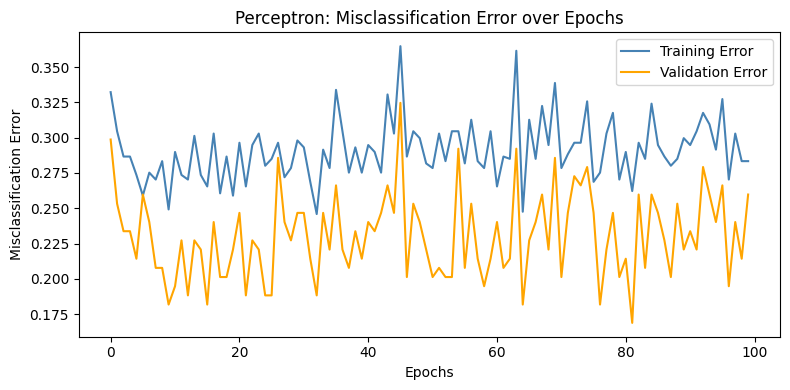

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.train_errors = []
        self.val_errors = []

    def _step(self, z):
        return (z >= 0).astype(int)

    def fit(self, X_train, y_train, X_val, y_val):
        n_samples, n_features = X_train.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            for xi, yi in zip(X_train, y_train):
                y_hat = self._step(np.dot(xi, self.weights) + self.bias)
                update = self.lr * (yi - y_hat)
                self.weights += update * xi
                self.bias   += update

            train_preds = self._step(X_train @ self.weights + self.bias)
            val_preds   = self._step(X_val   @ self.weights + self.bias)
            self.train_errors.append(np.mean(train_preds != y_train))
            self.val_errors.append(np.mean(val_preds   != y_val))

    def predict(self, X):
        return self._step(X @ self.weights + self.bias)


perceptron = Perceptron(learning_rate=0.01, n_iterations=100)
perceptron.fit(X_train, y_train, X_test, y_test)
y_pred_perceptron = perceptron.predict(X_test)

print_metrics("Perceptron", y_test, y_pred_perceptron)

plt.figure(figsize=(8, 4))
plt.plot(perceptron.train_errors, label="Training Error",   color="steelblue")
plt.plot(perceptron.val_errors,   label="Validation Error", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Misclassification Error")
plt.title("Perceptron: Misclassification Error over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Logistic Regression (from Scratch)


  Model: Logistic Regression
  Confusion Matrix:
[[79 20]
 [18 37]]
  Accuracy  : 0.7532
  Precision : 0.6491
  Recall    : 0.6727
  F1 Score  : 0.6607


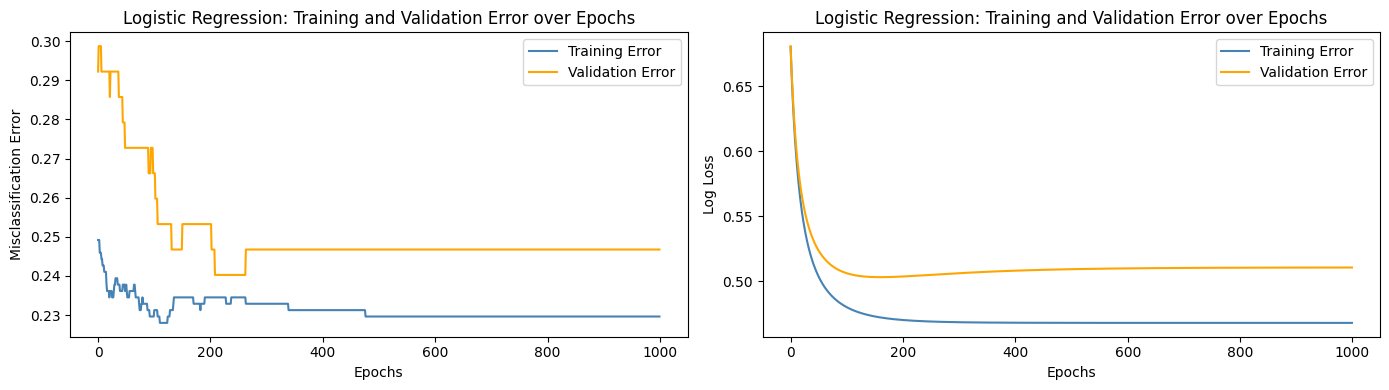

In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.train_misclass = []
        self.val_misclass   = []
        self.train_logloss  = []
        self.val_logloss    = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X_train, y_train, X_val, y_val):
        n_samples, n_features = X_train.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            z        = X_train @ self.weights + self.bias          # linear combination
            y_hat    = self._sigmoid(z)                            # predicted probabilities
            error    = y_hat - y_train                             # error vector
            dw       = (X_train.T @ error) / n_samples            # gradient w.r.t weights
            db       = np.mean(error)                              # gradient w.r.t bias
            self.weights -= self.lr * dw         ==                  # update weights
            self.bias    -= self.lr * db                           # update bias

            train_probs = self._sigmoid(X_train @ self.weights + self.bias)
            val_probs   = self._sigmoid(X_val   @ self.weights + self.bias)

            self.train_misclass.append(misclassification_error(y_train, train_probs))
            self.val_misclass.append(  misclassification_error(y_val,   val_probs))
            self.train_logloss.append( log_loss(y_train, train_probs))
            self.val_logloss.append(   log_loss(y_val,   val_probs))

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


lr_model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
lr_model.fit(X_train, y_train, X_test, y_test)
y_pred_lr = lr_model.predict(X_test)

print_metrics("Logistic Regression", y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lr_model.train_misclass, label="Training Error",   color="steelblue")
axes[0].plot(lr_model.val_misclass,   label="Validation Error", color="orange")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Misclassification Error")
axes[0].set_title("Logistic Regression: Training and Validation Error over Epochs")
axes[0].legend()

axes[1].plot(lr_model.train_logloss, label="Training Error",   color="steelblue")
axes[1].plot(lr_model.val_logloss,   label="Validation Error", color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Log Loss")
axes[1].set_title("Logistic Regression: Training and Validation Error over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Naive Bayes (GaussianNB)

In [ ]:
def train_naive_bayes(X_train, y_train, X_test):
    nb_model = GaussianNB()
    nb_model.fit(X_train, y_train)
    y_pred = nb_model.predict(X_test)
    return nb_model, y_pred

nb_model, y_pred_nb = train_naive_bayes(X_train, y_train, X_test)

# Metrics
print_metrics("Naive Bayes (GaussianNB)", y_test, y_pred_nb)


  Model: Naive Bayes (GaussianNB)
  Confusion Matrix:
[[79 20]
 [16 39]]
  Accuracy  : 0.7662
  Precision : 0.6610
  Recall    : 0.7091
  F1 Score  : 0.6842


## 8. Summary Comparison

In [ ]:
models = {
    "Perceptron"         : y_pred_perceptron,
    "Logistic Regression": y_pred_lr,
    "Naive Bayes"        : y_pred_nb,
}

print(f"\n{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 60)
for name, preds in models.items():
    print(
        f"{name:<22}"
        f"{accuracy_score(y_test, preds):>9.4f}"
        f"{precision_score(y_test, preds):>10.4f}"
        f"{recall_score(y_test, preds):>8.4f}"
        f"{f1_score(y_test, preds):>8.4f}"
    )


Model                   Accuracy  Precision   Recall       F1
------------------------------------------------------------
Perceptron               0.7403    0.7143  0.4545  0.5556
Logistic Regression      0.7532    0.6491  0.6727  0.6607
Naive Bayes              0.7662    0.6610  0.7091  0.6842
